[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/33%20-%20Deep%20Convolutional%20Neural%20Networks/Deep_Convolutional_Neural_Networks.ipynb)

# Overview

## 'Deep' Convolutional Neural Networks 

We'll explore how adding layers to a network can improve its accuracy (though at the cost of computation). 

![DeepCNN](https://www.dropbox.com/s/vbxbpp6foai6rsp/CNN-diagram.jpeg?raw=1)

## Data

We'll use the cifar100 dataset. In order to keep the dataset size small enough to be trained in a reasonable amount of time in a Google Colab, let's start with just two classes from the dataset - **cats and dogs**.



In [0]:
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers.convolutional import Conv2D, MaxPooling2D
from keras import backend as K

if K.backend()=='tensorflow':
  K.set_image_dim_ordering("th")

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train.shape:", x_train.shape)

Using TensorFlow backend.


x_train.shape: (50000, 3, 32, 32)


dimension of images: 32 32


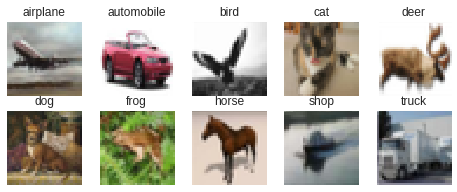

In [0]:
# input image dimensions
img_rows, img_cols = x_train[0].shape[1], x_train[0].shape[2]
print("dimension of images:", img_rows, img_cols)

# Plot sample image from each cifar10 class
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','shop','truck']
fig = plt.figure(figsize=(8,3))
for i in range(10):  
  ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
  idx = np.where(y_train[:]==i)[0]
  features_idx = x_train[idx,::]  
  random_img_num = np.random.randint(features_idx.shape[0])
  im = np.transpose(features_idx[random_img_num,::],(1,2,0))  
  ax.set_title(class_names[i])
  plt.imshow(im)
plt.show()

# Only look at cats [=3] and dogs [=5]
# create boolean arrays for train and test targets
train_picks = np.ravel(np.logical_or(y_train==3, y_train==5))
test_picks = np.ravel(np.logical_or(y_test==3, y_test==5))

# filter train and test datasets based on boolean arrays
x_train = x_train[train_picks]
x_test = x_test[test_picks]

# prepare y_train and y_test for dogs=True(1) and cats=False(0)
y_train = np.array(y_train[train_picks]==5,dtype=int)
y_test = np.array(y_test[test_picks]==5,dtype=int)

# check for image_data format and format image shape accordingly
if K.image_data_format() == 'channels_first':
  x_train = x_train.reshape(x_train.shape[0], 3, img_rows, img_cols)
  x_test = x_test.reshape(x_test.shape[0], 3, img_rows, img_cols)
  input_shape = (3, img_rows, img_cols)
else:
  x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 3)
  x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 3)
  input_shape = (img_rows, img_cols, 3)

### Normalization

Scale pixel values to be b/w 0 and 1

In [0]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Convert class vectors to binary class matrices
num_classes = 2
y_train = keras.utils.to_categorical(np.ravel(y_train), num_classes)
y_test = keras.utils.to_categorical(np.ravel(y_test), num_classes)

# Check train and test lengths
print('y_train length:', len(y_train))
print('x_train length:', len(x_train))
print('y_test length:', len(y_test))
print('x_test length:', len(x_test))

y_train length: 10000
x_train length: 10000
y_test length: 2000
x_test length: 2000


In [0]:
# Important Hyperparameters
batch_size = 32 
epochs = 100

# Model #1

We start with the simplest possible model

*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Max Pooling - pool_size = (2,2)
*   Dropout - use .25 for all layers but the final dropout layer
---
*   Flatten
*   Fully-Connected (Dense)
*   Dropout - use .5 this time 
*   Fully-Connected (Dense layer where # neurons = # final classes/labels)


We compile the model using categorical_crossentropy as our loss metric, use the Adam optimizer, and accuracy as the overall scoring metric. 



In [0]:
model = Sequential()
model.add(Conv2D(4, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy, 
              optimizer=keras.optimizers.Adam(), 
              metrics=['accuracy'])

np.random.seed(42)

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 4, 30, 30)         112       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 8, 28, 28)         296       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 8, 14, 14)         0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 8, 14, 14)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1568)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 16)                25104     
_________________________________________________________________
dropout_2 (Dropout)          (None, 16)                0         
__________

## Fit the model

Let's fit our model and save it to a new variable so that we can access the .history value to make a plot of our training and validation accuracies by epoch

In [0]:
fitted_model = model.fit(x_train, 
                         y_train, 
                         batch_size=batch_size, 
                         epochs=epochs, 
                         validation_data=(x_test, y_test), 
                         shuffle=True)

Train on 10000 samples, validate on 2000 samples
Epoch 1/100
10000/10000 [==============================] - 4s 378us/step - loss: 0.6947 - acc: 0.4929 - val_loss: 0.6932 - val_acc: 0.5000
Epoch 2/100
10000/10000 [==============================] - 3s 300us/step - loss: 0.6933 - acc: 0.4911 - val_loss: 0.6932 - val_acc: 0.5000
Epoch 3/100
10000/10000 [==============================] - 3s 299us/step - loss: 0.6897 - acc: 0.5172 - val_loss: 0.6729 - val_acc: 0.5710
Epoch 4/100
10000/10000 [==============================] - 3s 298us/step - loss: 0.6614 - acc: 0.5982 - val_loss: 0.6178 - val_acc: 0.6565
Epoch 5/100
 6656/10000 [==================>...........] - ETA: 0s - loss: 0.6234 - acc: 0.6540

10000/10000 [==============================] - 3s 298us/step - loss: 0.6203 - acc: 0.6554 - val_loss: 0.5974 - val_acc: 0.6700
Epoch 6/100
10000/10000 [==============================] - 3s 298us/step - loss: 0.6005 - acc: 0.6709 - val_loss: 0.5960 - val_acc: 0.6685
Epoch 7/100
10000/10000 [==============================] - 3s 300us/step - loss: 0.5866 - acc: 0.6862 - val_loss: 0.5819 - val_acc: 0.6750
Epoch 8/100
10000/10000 [==============================] - 3s 301us/step - loss: 0.5794 - acc: 0.6897 - val_loss: 0.5815 - val_acc: 0.6800
Epoch 9/100
10000/10000 [==============================] - 3s 293us/step - loss: 0.5617 - acc: 0.7018 - val_loss: 0.5709 - val_acc: 0.6790
Epoch 10/100
 1344/10000 [===>..........................] - ETA: 2s - loss: 0.5547 - acc: 0.7158

10000/10000 [==============================] - 3s 298us/step - loss: 0.5531 - acc: 0.7085 - val_loss: 0.5695 - val_acc: 0.6880
Epoch 11/100
10000/10000 [==============================] - 3s 296us/step - loss: 0.5503 - acc: 0.7089 - val_loss: 0.5644 - val_acc: 0.6875
Epoch 12/100
10000/10000 [==============================] - 3s 295us/step - loss: 0.5404 - acc: 0.7185 - val_loss: 0.5658 - val_acc: 0.6975
Epoch 13/100
10000/10000 [==============================] - 3s 299us/step - loss: 0.5342 - acc: 0.7241 - val_loss: 0.5534 - val_acc: 0.7060
Epoch 14/100
10000/10000 [==============================] - 3s 300us/step - loss: 0.5291 - acc: 0.7256 - val_loss: 0.5544 - val_acc: 0.7075
Epoch 15/100
  576/10000 [>.............................] - ETA: 2s - loss: 0.5239 - acc: 0.7552

10000/10000 [==============================] - 3s 299us/step - loss: 0.5183 - acc: 0.7352 - val_loss: 0.5470 - val_acc: 0.7095
Epoch 16/100
10000/10000 [==============================] - 3s 296us/step - loss: 0.5207 - acc: 0.7308 - val_loss: 0.5453 - val_acc: 0.6995
Epoch 17/100
10000/10000 [==============================] - 3s 291us/step - loss: 0.5116 - acc: 0.7354 - val_loss: 0.5436 - val_acc: 0.7025
Epoch 18/100
10000/10000 [==============================] - 3s 292us/step - loss: 0.4995 - acc: 0.7452 - val_loss: 0.5422 - val_acc: 0.7115
Epoch 19/100
10000/10000 [==============================] - 3s 291us/step - loss: 0.5069 - acc: 0.7370 - val_loss: 0.5463 - val_acc: 0.7130
Epoch 20/100
 1024/10000 [==>...........................] - ETA: 2s - loss: 0.4786 - acc: 0.7783

10000/10000 [==============================] - 3s 289us/step - loss: 0.4920 - acc: 0.7559 - val_loss: 0.5417 - val_acc: 0.7195
Epoch 21/100
10000/10000 [==============================] - 3s 298us/step - loss: 0.4919 - acc: 0.7502 - val_loss: 0.5431 - val_acc: 0.7145
Epoch 22/100
10000/10000 [==============================] - 3s 300us/step - loss: 0.4813 - acc: 0.7565 - val_loss: 0.5419 - val_acc: 0.7150
Epoch 23/100
10000/10000 [==============================] - 3s 298us/step - loss: 0.4845 - acc: 0.7546 - val_loss: 0.5609 - val_acc: 0.7135
Epoch 24/100
10000/10000 [==============================] - 3s 297us/step - loss: 0.4762 - acc: 0.7568 - val_loss: 0.5425 - val_acc: 0.7200
Epoch 25/100
  800/10000 [=>............................] - ETA: 2s - loss: 0.4559 - acc: 0.7913

...

10000/10000 [==============================] - 3s 294us/step - loss: 0.3790 - acc: 0.8076 - val_loss: 0.5608 - val_acc: 0.7390
Epoch 81/100
10000/10000 [==============================] - 3s 295us/step - loss: 0.3737 - acc: 0.8107 - val_loss: 0.5772 - val_acc: 0.7325
Epoch 82/100
10000/10000 [==============================] - 3s 297us/step - loss: 0.3711 - acc: 0.8105 - val_loss: 0.5491 - val_acc: 0.7375
Epoch 83/100
10000/10000 [==============================] - 3s 300us/step - loss: 0.3849 - acc: 0.8033 - val_loss: 0.5468 - val_acc: 0.7370
Epoch 84/100
10000/10000 [==============================] - 3s 299us/step - loss: 0.3678 - acc: 0.8147 - val_loss: 0.5700 - val_acc: 0.7350
Epoch 85/100
  608/10000 [>.............................] - ETA: 2s - loss: 0.4032 - acc: 0.7829

10000/10000 [==============================] - 3s 301us/step - loss: 0.3768 - acc: 0.8080 - val_loss: 0.5560 - val_acc: 0.7315
Epoch 86/100
10000/10000 [==============================] - 3s 302us/step - loss: 0.3669 - acc: 0.8161 - val_loss: 0.5624 - val_acc: 0.7345
Epoch 87/100
10000/10000 [==============================] - 3s 299us/step - loss: 0.3731 - acc: 0.8151 - val_loss: 0.5606 - val_acc: 0.7285
Epoch 88/100
10000/10000 [==============================] - 3s 297us/step - loss: 0.3642 - acc: 0.8155 - val_loss: 0.5731 - val_acc: 0.7285
Epoch 89/100
10000/10000 [==============================] - 3s 297us/step - loss: 0.3651 - acc: 0.8130 - val_loss: 0.5798 - val_acc: 0.7350
Epoch 90/100
  256/10000 [..............................] - ETA: 2s - loss: 0.3804 - acc: 0.8164

10000/10000 [==============================] - 3s 300us/step - loss: 0.3594 - acc: 0.8203 - val_loss: 0.5685 - val_acc: 0.7345
Epoch 91/100
10000/10000 [==============================] - 3s 298us/step - loss: 0.3724 - acc: 0.8136 - val_loss: 0.5659 - val_acc: 0.7295
Epoch 92/100
10000/10000 [==============================] - 3s 296us/step - loss: 0.3709 - acc: 0.8133 - val_loss: 0.5739 - val_acc: 0.7395
Epoch 93/100
10000/10000 [==============================] - 3s 296us/step - loss: 0.3802 - acc: 0.8129 - val_loss: 0.5656 - val_acc: 0.7370
Epoch 94/100
10000/10000 [==============================] - 3s 301us/step - loss: 0.3693 - acc: 0.8142 - val_loss: 0.5573 - val_acc: 0.7280
Epoch 95/100
  416/10000 [>.............................] - ETA: 2s - loss: 0.3217 - acc: 0.8293

10000/10000 [==============================] - 3s 298us/step - loss: 0.3680 - acc: 0.8166 - val_loss: 0.5658 - val_acc: 0.7250
Epoch 96/100
10000/10000 [==============================] - 3s 295us/step - loss: 0.3668 - acc: 0.8171 - val_loss: 0.5745 - val_acc: 0.7295
Epoch 97/100
10000/10000 [==============================] - 3s 296us/step - loss: 0.3664 - acc: 0.8175 - val_loss: 0.5798 - val_acc: 0.7315
Epoch 98/100
10000/10000 [==============================] - 3s 297us/step - loss: 0.3693 - acc: 0.8121 - val_loss: 0.5558 - val_acc: 0.7285
Epoch 99/100
10000/10000 [==============================] - 3s 303us/step - loss: 0.3638 - acc: 0.8173 - val_loss: 0.5836 - val_acc: 0.7360
Epoch 100/100
  448/10000 [>.............................] - ETA: 2s - loss: 0.3128 - acc: 0.8415

10000/10000 [==============================] - 3s 300us/step - loss: 0.3618 - acc: 0.8188 - val_loss: 0.5676 - val_acc: 0.7280


## Plot Training and Validation Accuracies

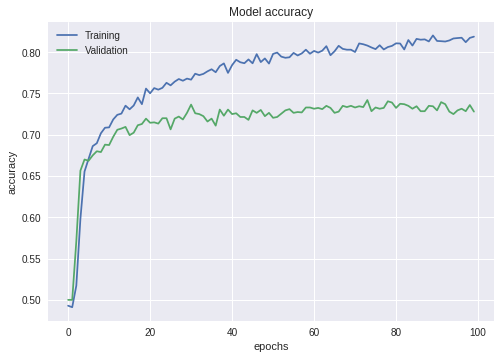

In [0]:
plt.plot(fitted_model.history['acc'], label="Training")
plt.plot(fitted_model.history['val_acc'], label="Validation")
plt.title("Model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show();

## Observation

There is significant delta between the Training and the Validation accuracies – this means our model is not generalizing well (not performing that well on unseen data). 

Let's see what happens if we increase the **depth** of the model – i.e. add more layers.

# Model #2

Lets add an additional set of convolutional -> activation -> pooling to this model

*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Max Pooling - pool_size = (2,2)
*   Dropout - use .25 for all layers but the final layer
---
*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Conv2D - kernel_size = (3,3)
*   Relu Activation
*   Max Pooling - pool_size = (2,2)
*   Dropout - use .25 for all layers but the final layer
---
*   Flatten
*   Fully-Connected (Dense)
*   Dropout - use .5 this time 
*   Fully-Connected (Dense layer where # neurons = # final classes/labels)

Again, we compile the model using categorical_crossentropy as your loss metric and use the Adam optimizer, and accuracy as your overall scoring metric. 

In [0]:
model = Sequential()
model.add(Conv2D(4, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(4, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy, 
              optimizer=keras.optimizers.Adam(), 
              metrics=['accuracy'])

np.random.seed(42)
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 4, 30, 30)         112       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 8, 28, 28)         296       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 8, 14, 14)         0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 8, 14, 14)         0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 4, 12, 12)         292       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 8, 10, 10)         296       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 8, 5, 5)           0         
__________

## Fit the model

In [0]:
fitted_model = model.fit(x_train, 
                         y_train, 
                         batch_size=batch_size, 
                         epochs=epochs, 
                         validation_data=(x_test, y_test), 
                         shuffle=True)

Train on 10000 samples, validate on 2000 samples
Epoch 1/100
10000/10000 [==============================] - 4s 414us/step - loss: 0.6890 - acc: 0.5366 - val_loss: 0.6746 - val_acc: 0.6080
Epoch 2/100
10000/10000 [==============================] - 4s 379us/step - loss: 0.6681 - acc: 0.6029 - val_loss: 0.6550 - val_acc: 0.6260
Epoch 3/100
10000/10000 [==============================] - 4s 379us/step - loss: 0.6504 - acc: 0.6210 - val_loss: 0.6214 - val_acc: 0.6720
Epoch 4/100
10000/10000 [==============================] - 4s 375us/step - loss: 0.6377 - acc: 0.6424 - val_loss: 0.6143 - val_acc: 0.6880
Epoch 5/100
 1312/10000 [==>...........................] - ETA: 3s - loss: 0.6286 - acc: 0.6639

10000/10000 [==============================] - 4s 378us/step - loss: 0.6275 - acc: 0.6490 - val_loss: 0.5901 - val_acc: 0.7010
Epoch 6/100
10000/10000 [==============================] - 4s 371us/step - loss: 0.6204 - acc: 0.6577 - val_loss: 0.6052 - val_acc: 0.6805
Epoch 7/100
10000/10000 [==============================] - 4s 377us/step - loss: 0.6161 - acc: 0.6603 - val_loss: 0.5997 - val_acc: 0.6850
Epoch 8/100
10000/10000 [==============================] - 4s 376us/step - loss: 0.6111 - acc: 0.6655 - val_loss: 0.5807 - val_acc: 0.6920
Epoch 9/100
 5536/10000 [===============>..............] - ETA: 1s - loss: 0.6034 - acc: 0.6752

10000/10000 [==============================] - 4s 379us/step - loss: 0.6029 - acc: 0.6745 - val_loss: 0.5849 - val_acc: 0.6985
Epoch 10/100
10000/10000 [==============================] - 4s 378us/step - loss: 0.5975 - acc: 0.6827 - val_loss: 0.5921 - val_acc: 0.6775
Epoch 11/100
10000/10000 [==============================] - 4s 379us/step - loss: 0.5965 - acc: 0.6810 - val_loss: 0.5730 - val_acc: 0.7025
Epoch 12/100
10000/10000 [==============================] - 4s 374us/step - loss: 0.5947 - acc: 0.6834 - val_loss: 0.5570 - val_acc: 0.7125
Epoch 13/100
 5792/10000 [================>.............] - ETA: 1s - loss: 0.5802 - acc: 0.6837

10000/10000 [==============================] - 4s 376us/step - loss: 0.5861 - acc: 0.6854 - val_loss: 0.5846 - val_acc: 0.6835
Epoch 14/100
10000/10000 [==============================] - 4s 378us/step - loss: 0.5876 - acc: 0.6904 - val_loss: 0.5668 - val_acc: 0.7040
Epoch 15/100
10000/10000 [==============================] - 4s 380us/step - loss: 0.5774 - acc: 0.6986 - val_loss: 0.5541 - val_acc: 0.7135
Epoch 16/100
10000/10000 [==============================] - 4s 372us/step - loss: 0.5784 - acc: 0.7007 - val_loss: 0.5558 - val_acc: 0.7120
Epoch 17/100
 6112/10000 [=================>............] - ETA: 1s - loss: 0.5694 - acc: 0.7021

10000/10000 [==============================] - 4s 373us/step - loss: 0.5727 - acc: 0.7008 - val_loss: 0.5552 - val_acc: 0.7240
Epoch 18/100
10000/10000 [==============================] - 4s 375us/step - loss: 0.5743 - acc: 0.6996 - val_loss: 0.5510 - val_acc: 0.7180
Epoch 19/100
10000/10000 [==============================] - 4s 375us/step - loss: 0.5683 - acc: 0.7054 - val_loss: 0.5546 - val_acc: 0.7065
Epoch 20/100
10000/10000 [==============================] - 4s 367us/step - loss: 0.5634 - acc: 0.7089 - val_loss: 0.5325 - val_acc: 0.7390
Epoch 21/100
 6080/10000 [=================>............] - ETA: 1s - loss: 0.5696 - acc: 0.7102

...

10000/10000 [==============================] - 4s 373us/step - loss: 0.5124 - acc: 0.7455 - val_loss: 0.5032 - val_acc: 0.7470
Epoch 82/100
10000/10000 [==============================] - 4s 370us/step - loss: 0.5146 - acc: 0.7448 - val_loss: 0.5110 - val_acc: 0.7370
Epoch 83/100
10000/10000 [==============================] - 4s 370us/step - loss: 0.5155 - acc: 0.7485 - val_loss: 0.5051 - val_acc: 0.7340
Epoch 84/100
10000/10000 [==============================] - 4s 375us/step - loss: 0.5130 - acc: 0.7497 - val_loss: 0.4906 - val_acc: 0.7460
Epoch 85/100
 6368/10000 [==================>...........] - ETA: 1s - loss: 0.5055 - acc: 0.7527

10000/10000 [==============================] - 4s 371us/step - loss: 0.5067 - acc: 0.7521 - val_loss: 0.4999 - val_acc: 0.7430
Epoch 86/100
10000/10000 [==============================] - 4s 373us/step - loss: 0.5115 - acc: 0.7496 - val_loss: 0.5302 - val_acc: 0.7230
Epoch 87/100
10000/10000 [==============================] - 4s 373us/step - loss: 0.5091 - acc: 0.7496 - val_loss: 0.5021 - val_acc: 0.7450
Epoch 88/100
10000/10000 [==============================] - 4s 378us/step - loss: 0.5097 - acc: 0.7470 - val_loss: 0.5308 - val_acc: 0.7250
Epoch 89/100
 6112/10000 [=================>............] - ETA: 1s - loss: 0.5030 - acc: 0.7538

10000/10000 [==============================] - 4s 376us/step - loss: 0.5060 - acc: 0.7537 - val_loss: 0.4989 - val_acc: 0.7470
Epoch 90/100
10000/10000 [==============================] - 4s 374us/step - loss: 0.5098 - acc: 0.7467 - val_loss: 0.4809 - val_acc: 0.7630
Epoch 91/100
10000/10000 [==============================] - 4s 375us/step - loss: 0.5074 - acc: 0.7565 - val_loss: 0.5008 - val_acc: 0.7375
Epoch 92/100
10000/10000 [==============================] - 4s 373us/step - loss: 0.5070 - acc: 0.7472 - val_loss: 0.5188 - val_acc: 0.7360
Epoch 93/100
 6208/10000 [=================>............] - ETA: 1s - loss: 0.5128 - acc: 0.7489

10000/10000 [==============================] - 4s 376us/step - loss: 0.5096 - acc: 0.7504 - val_loss: 0.5087 - val_acc: 0.7290
Epoch 94/100
10000/10000 [==============================] - 4s 376us/step - loss: 0.5067 - acc: 0.7551 - val_loss: 0.4848 - val_acc: 0.7580
Epoch 95/100
10000/10000 [==============================] - 4s 381us/step - loss: 0.5072 - acc: 0.7533 - val_loss: 0.5025 - val_acc: 0.7325
Epoch 96/100
10000/10000 [==============================] - 4s 376us/step - loss: 0.5032 - acc: 0.7533 - val_loss: 0.5370 - val_acc: 0.7265
Epoch 97/100
 6048/10000 [=================>............] - ETA: 1s - loss: 0.4995 - acc: 0.7555

10000/10000 [==============================] - 4s 377us/step - loss: 0.5061 - acc: 0.7532 - val_loss: 0.5172 - val_acc: 0.7265
Epoch 98/100
10000/10000 [==============================] - 4s 374us/step - loss: 0.5047 - acc: 0.7519 - val_loss: 0.4881 - val_acc: 0.7530
Epoch 99/100
10000/10000 [==============================] - 4s 377us/step - loss: 0.5052 - acc: 0.7531 - val_loss: 0.4836 - val_acc: 0.7580
Epoch 100/100
10000/10000 [==============================] - 4s 378us/step - loss: 0.5018 - acc: 0.7520 - val_loss: 0.4895 - val_acc: 0.7535


## Plot Training and Validation Accuracies

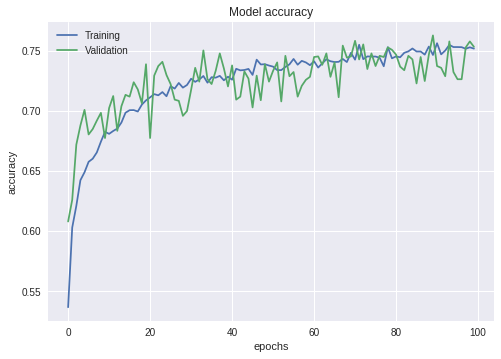

In [0]:
plt.plot(fitted_model.history['acc'], label="Training")
plt.plot(fitted_model.history['val_acc'], label="Validation")
plt.title("Model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show();

## Observation

Even though the Training accuracy decreased a bit, the Validation accuracy seems to have caught up with the Training accuracy – which is the correct direction of how we want our model to behave.

*   There is no point of having a model which performs perfectly on the training data, but fails on unseen data (Overfitting – Deep Neural Networks are notorious for having the power to just memorize the training data)
*   The above means our 2nd model generalizes much better than our 1st model – which is what we were after. Now, this doesn't mean its as simple as adding more layers – but **in general**, with the right tuning, adding more layers is 1 technique which Deep Learning exploits to squeeze the best performance out of the models.

